# Sleep Health and Lifestyle — Predictive Modeling

#### Edwin Alonso Pérez Brenes

Este cuaderno documenta un análisis exploratorio y predictivo sobre el conjunto de datos **Sleep Health and Lifestyle**.  
El objetivo principal es identificar qué variables se asocian con la **calidad del sueño** y evaluar qué enfoque predictivo ofrece el mejor equilibrio entre desempeño e interpretabilidad.

**Fuente del conjunto de datos:**  
<https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset?resource=download>

**Preguntas guía del análisis**
- ¿Qué variables muestran asociación con la calidad del sueño?
- ¿Qué modelo predice mejor: una red neuronal estándar o Elastic Net?
- ¿Qué factores dominan la predicción final del modelo seleccionado?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 1. Carga y revisión inicial de los datos

Se carga el conjunto de datos y se realiza una inspección preliminar para verificar estructura, variables disponibles y consistencia general.

In [2]:
data= pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## 2. Preparación inicial de variables

En esta etapa se realizan tres decisiones de preprocesamiento:

1. **`BMI Category`** se codifica de forma ordinal para preservar su orden natural:
   - Normal / Normal Weight = 0  
   - Overweight = 1  
   - Obese = 2
2. Se elimina **`Person ID`**, ya que es un identificador y no aporta información predictiva.
3. Se elimina la variable con mayor cantidad de datos faltantes. En este conjunto, la variable excluida fue la que concentraba los faltantes, con el fin de trabajar con un conjunto consistente para el modelado.

El resumen siguiente permite verificar que, tras esta etapa, el conjunto de datos queda libre de valores faltantes en las variables retenidas.

In [3]:
#Pasar BMI a variable ordinales
mapa_bmi = {
    'Normal Weight': 0,
    'Normal': 0,
    'Overweight': 1,
    'Obese': 2
}

data['BMI_ordinal'] = data['BMI Category'].map(mapa_bmi)

# Datos faltantes:

data = data.drop(columns= 'Person ID')
data = data.drop(columns= data.isna().sum().idxmax())

pd.DataFrame({
    'NA': data.isna().sum(),
    'no_NA': data.notna().sum(),
    'total': len(data)
})


,NA,no_NA,total
Gender,0,374,374
Age,0,374,374
Occupation,0,374,374
Sleep Duration,0,374,374
Quality of Sleep,0,374,374
Physical Activity Level,0,374,374
Stress Level,0,374,374
BMI Category,0,374,374
Blood Pressure,0,374,374
Heart Rate,0,374,374


**Comentario:** trabajar sin faltantes simplifica la comparación entre modelos y evita introducir variabilidad adicional por imputación. En este caso, la limpieza resultante permite concentrarse en la estructura predictiva del conjunto.

## 3. Correlaciones entre variables numéricas

La matriz de correlación permite identificar asociaciones lineales preliminares entre las variables cuantitativas.  
Esta etapa no prueba causalidad, pero sí ayuda a detectar relaciones esperables y posibles redundancias entre predictores.

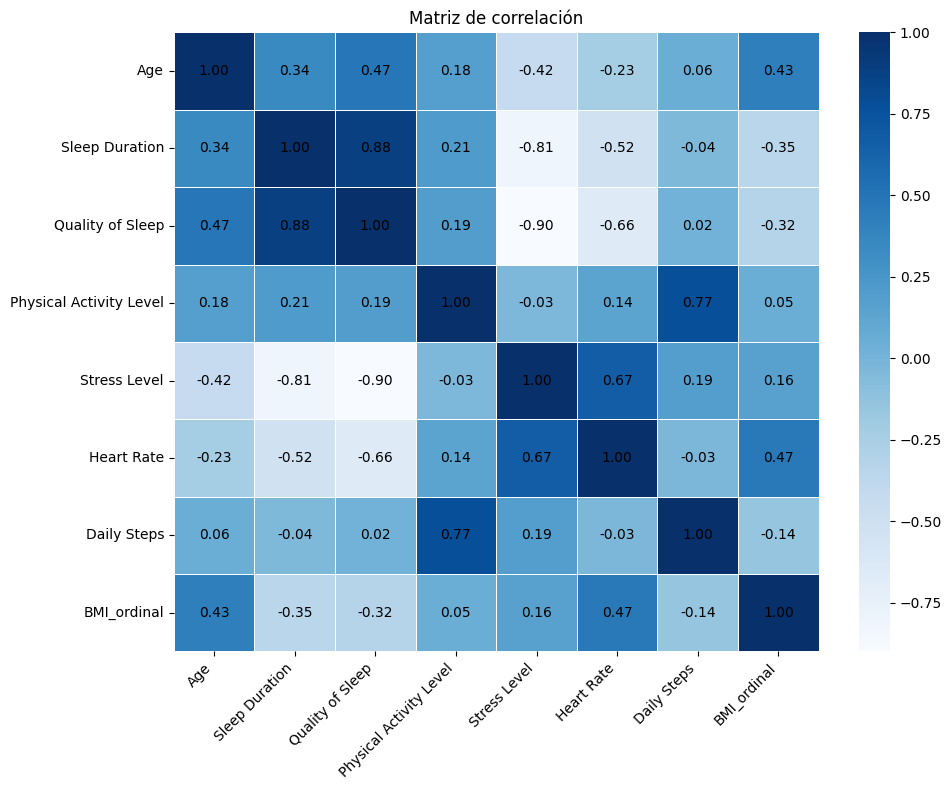

In [4]:
# Gráfico de correlaciones
corr = data.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    cmap='Blues',
    cbar=True,
    linewidths=0.5,
    linecolor='white'
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        valor = corr.iloc[i, j]
        ax.text(
            j + 0.5, i + 0.5,
            f"{valor:.2f}",
            ha='center', va='center',
            color='black', fontsize=10
        )

plt.title('Matriz de correlación')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura general de la matriz:** las asociaciones más útiles para el modelado son aquellas que muestran dirección consistente y magnitud apreciable con respecto a `Quality of Sleep`. Esta revisión se complementa luego con el ajuste del modelo, que evalúa el efecto conjunto de todas las variables y no solo relaciones bivariadas.

## 4. Revisión de asimetría

Se evalúa la asimetría de las variables numéricas para detectar distribuciones fuertemente sesgadas que puedan motivar transformaciones.  
El caso más notable es **`Heart Rate`**, que presenta una asimetría positiva marcada.

In [5]:
asimetria = data.select_dtypes(include='number').skew()
print(asimetria)

Age                        0.257222
Sleep Duration             0.037554
Quality of Sleep          -0.207448
Physical Activity Level    0.074487
Stress Level               0.154330
Heart Rate                 1.224824
Daily Steps                0.178277
BMI_ordinal                0.690449
dtype: float64


El histograma siguiente permite confirmar visualmente la cola derecha de `Heart Rate`. Sin embargo, una alta asimetría marginal **no obliga por sí sola** a transformar un predictor; antes de hacerlo conviene revisar si la relación con la variable respuesta es aproximadamente lineal.

c:\Users\Sosy0\Documents\WPy64-31150\python-3.11.5.amd64\Lib\site-packages\seaborn\_oldcore.py:1124: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


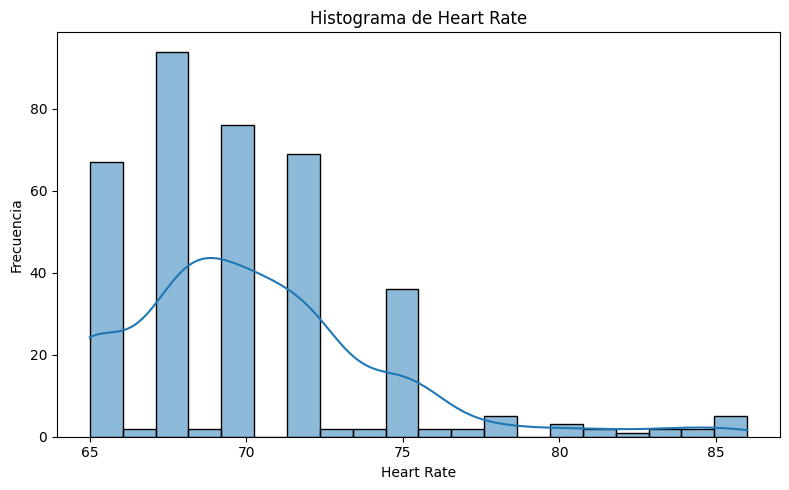

In [6]:
variable = 'Heart Rate' 

plt.figure(figsize=(8, 5))
sns.histplot(data[variable].dropna(), bins=20, kde=True)

plt.title(f'Histograma de {variable}')
plt.xlabel(variable)
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

## 5. Relación entre `Heart Rate` y `Quality of Sleep`

Aunque `Heart Rate` presenta asimetría alta, la decisión de transformarlo debe basarse en su relación con la respuesta.  
Se inspecciona la relación bivariada con una recta de regresión para verificar si existe una tendencia aproximadamente lineal.

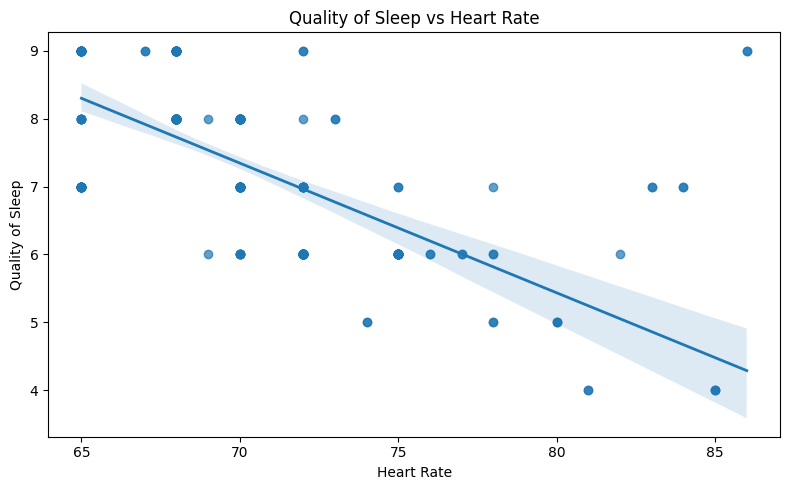

In [7]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=data,
    x='Heart Rate',
    y='Quality of Sleep',
    scatter_kws={'alpha': 0.7},
    line_kws={'linewidth': 2}
)

plt.title('Quality of Sleep vs Heart Rate')
plt.xlabel('Heart Rate')
plt.ylabel('Quality of Sleep')
plt.tight_layout()
plt.show()

**Conclusión de esta revisión:** se observa una **tendencia negativa aproximadamente lineal** entre `Heart Rate` y `Quality of Sleep`: a mayores valores de frecuencia cardíaca, tiende a observarse una menor calidad del sueño.  
Dado que no se aprecia una curvatura fuerte que justifique una transformación, se conserva `Heart Rate` en su **escala original** para no perder interpretabilidad.

## 6. Variables incluidas en el modelado

Para el primer ejercicio predictivo se eliminan las variables categóricas nominales y se conserva la versión ordinal de `BMI Category`.  
De este modo, el modelo se construye únicamente con variables numéricas y una variable ordinal codificada.

In [8]:
#Eliminar variables categóricas

data = data.drop(columns= 'Gender')
data = data.drop(columns= 'Occupation')
data = data.drop(columns= 'Blood Pressure')
data = data.drop(columns= 'BMI Category')

data

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BMI_ordinal
0,27,6.1,6,42,6,77,4200,1
1,28,6.2,6,60,8,75,10000,0
2,28,6.2,6,60,8,75,10000,0
3,28,5.9,4,30,8,85,3000,2
4,28,5.9,4,30,8,85,3000,2
...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,1
370,59,8.0,9,75,3,68,7000,1
371,59,8.1,9,75,3,68,7000,1
372,59,8.1,9,75,3,68,7000,1


**Nota metodológica:** esta decisión favorece un modelo más simple y totalmente interpretable. Como trabajo futuro, podría compararse esta estrategia con una codificación *one-hot* de las variables categóricas para evaluar si se gana capacidad predictiva.

## 7. Comparación de modelos predictivos

Se comparan dos enfoques:

- **Elastic Net**, que combina regularización L1 y L2 y mantiene interpretabilidad.
- **MLPRegressor**, una red neuronal estándar capaz de capturar relaciones no lineales.

La comparación se realiza mediante **validación cruzada repetida de 10 folds con 5 repeticiones**, lo que equivale a evaluar el desempeño sobre 50 particiones distintas del conjunto.  
Se reportan tres métricas:
- **RMSE**: penaliza más los errores grandes.
- **MAE**: error absoluto medio.
- **R²**: proporción de variabilidad explicada.

In [10]:
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.neural_network import MLPRegressor

# Variable respuesta
y = data['Quality of Sleep']

# Predictores
X = data.drop(columns=['Quality of Sleep'])

# Separación 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42
)

# Modelo Elastic Net
pipe_enet = Pipeline([
    ('prep', 'passthrough'),
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42))
])

# Modelo red neuronal
pipe_mlp = Pipeline([
    ('prep', 'passthrough'),
    ('model', MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=2000,
        random_state=42
    ))
])

# Validación cruzada solo en training
cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

res_enet = cross_validate(pipe_enet, X_train, y_train, cv=cv, scoring=scoring)
res_mlp = cross_validate(pipe_mlp, X_train, y_train, cv=cv, scoring=scoring)

print('Elastic Net (CV)')
print('RMSE:', -res_enet['test_rmse'].mean())
print('MAE :', -res_enet['test_mae'].mean())
print('R2  :',  res_enet['test_r2'].mean())

print('\nMLP Regressor (CV)')
print('RMSE:', -res_mlp['test_rmse'].mean())
print('MAE :', -res_mlp['test_mae'].mean())
print('R2  :',  res_mlp['test_r2'].mean())

Elastic Net (CV)
RMSE: 0.36588271840945674
MAE : 0.27932870083998745
R2  : 0.8974634102031174

MLP Regressor (CV)
RMSE: 1.7632189205209687
MAE : 1.408525931604836
R2  : -1.677034540079805


### Resultado de la comparación

Los resultados obtenidos fueron:

- **Elastic Net**  
  - RMSE = **0.367**  
  - MAE = **0.279**  
  - R² = **0.897**
- **MLP Regressor**  
  - RMSE = **1.763**  
  - MAE = **1.409**  
  - R² = **-1,677**

**Interpretación:** Elastic Net supera ampliamente a la red neuronal en las tres métricas. En particular, un R² cercano a 0.90 indica que el modelo lineal regularizado captura gran parte de la variabilidad observada en `Quality of Sleep`, mientras que la red neuronal presenta un desempeño claramente inestable para este conjunto de datos.

Por lo tanto, para este problema y con este tamaño de muestra, un modelo lineal regularizado resulta más adecuado que una red neuronal estándar. El resultado sugiere que la estructura predictiva dominante del conjunto es esencialmente lineal o casi lineal.

Dado que **Elastic Net** fue el modelo con mejor desempeño y, además, conserva interpretabilidad, se ajusta ahora un **modelo final** sobre todo el conjunto de datos para analizar sus coeficientes y extraer conclusiones sustantivas.

## 8. Ajuste del modelo final e interpretación de coeficientes

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelo final entrenado solo con el conjunto de entrenamiento
pipe_enet_final = Pipeline([
    ('prep', 'passthrough'),
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=42))
])

pipe_enet_final.fit(X_train, y_train)

# Extraer modelo entrenado
modelo = pipe_enet_final.named_steps['model']

# Intercepto
print("Intercepto:", modelo.intercept_)

# Coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo.coef_
})

coef_df['Abs'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values(by='Abs', ascending=False)

print(coef_df[['Variable', 'Coeficiente']])


y_pred_test = pipe_enet_final.predict(X_test)

print("\nDesempeño en test")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("R2  :", r2_score(y_test, y_pred_test))

Intercepto: 7.551483128506558
                  Variable  Coeficiente
3             Stress Level    -0.361086
1           Sleep Duration     0.338065
6              BMI_ordinal    -0.200089
4               Heart Rate    -0.028763
0                      Age     0.022515
2  Physical Activity Level     0.006224
5              Daily Steps     0.000012

Desempeño en test
RMSE: 0.3160738607317302
MAE : 0.2627111759710894
R2  : 0.933778858639174


Los coeficientes estimados muestran la dirección del efecto de cada predictor sobre `Quality of Sleep`, manteniendo constantes las demás variables:

- **Coeficiente positivo:** al aumentar la variable, tiende a aumentar la calidad del sueño.
- **Coeficiente negativo:** al aumentar la variable, tiende a disminuir la calidad del sueño.

A partir del ajuste final se observan tres resultados particularmente claros:

1. **`Stress Level`** tiene el coeficiente negativo de mayor magnitud.  
   Esto respalda la idea de que mayores niveles de estrés se asocian con peor calidad de sueño.
2. **`Sleep Duration`** presenta un coeficiente positivo alto.  
   Dormir más horas se asocia con una mejor calidad del sueño.
3. **`BMI_ordinal`** tiene un coeficiente negativo importante.  
   Pasar de una categoría de IMC más favorable a otra menos favorable se asocia con una disminución en la calidad del sueño.

En contraste, variables como **`Physical Activity Level`** y especialmente **`Daily Steps`** muestran una contribución mucho menor dentro del modelo ajustado.

**Observación:** el coeficiente de `Daily Steps` es prácticamente nulo. Dentro del modelo lineal regularizado, esto sugiere que su aporte marginal adicional es muy pequeño una vez que ya se consideran variables más informativas como estrés, duración del sueño, IMC y frecuencia cardíaca.

El siguiente gráfico resume la magnitud de los coeficientes no nulos del modelo:

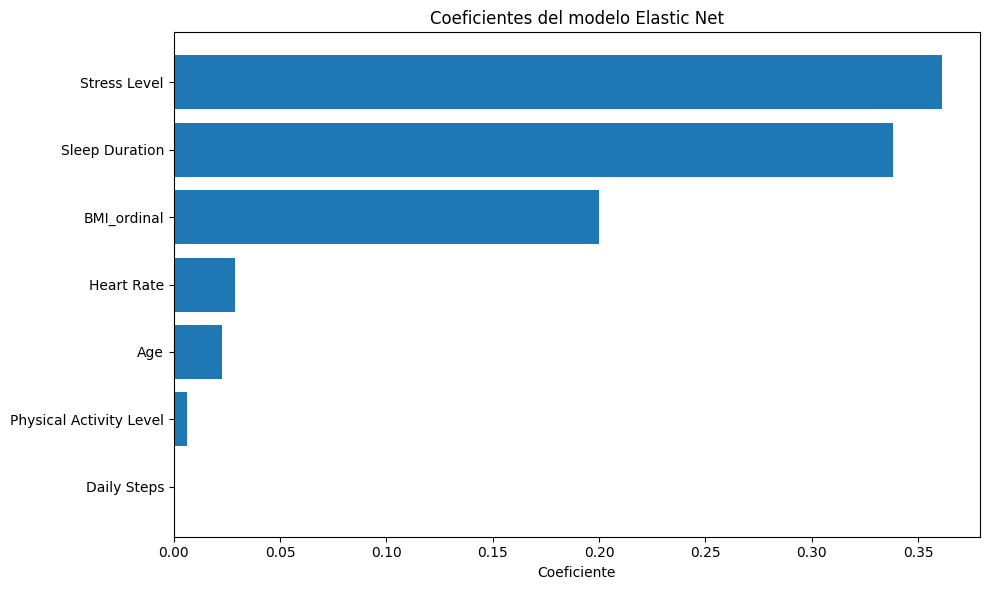

In [12]:
coef_plot = coef_df[coef_df['Coeficiente'] != 0].copy()

plt.figure(figsize=(10, 6))
plt.barh(coef_plot['Variable'], np.abs(coef_plot['Coeficiente']))
plt.xlabel('Coeficiente')
plt.title('Coeficientes del modelo Elastic Net')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Contribución relativa de los predictores

Para complementar la lectura de los coeficientes, se calcula una contribución relativa basada en la magnitud absoluta de cada coeficiente.  
Esta visualización sirve como **resumen descriptivo del modelo**, aunque debe interpretarse con cautela: resume la importancia relativa dentro del ajuste lineal obtenido y **no debe entenderse como causalidad**.

In [13]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

coef_df['AbsCoef'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values(by='AbsCoef', ascending=False)

# contribución relativa en porcentaje
coef_df['Contribucion_rel_%'] = 100 * coef_df['AbsCoef'] / coef_df['AbsCoef'].sum()

print("Intercepto:", modelo.intercept_)
print(coef_df[['Variable', 'Coeficiente', 'Contribucion_rel_%']])

Intercepto: 7.551483128506558
                  Variable  Coeficiente  Contribucion_rel_%
3             Stress Level    -0.361086           37.740725
1           Sleep Duration     0.338065           35.334538
6              BMI_ordinal    -0.200089           20.913329
4               Heart Rate    -0.028763            3.006319
0                      Age     0.022515            2.353253
2  Physical Activity Level     0.006224            0.650573
5              Daily Steps     0.000012            0.001263


<Figure size 900x800 with 0 Axes>

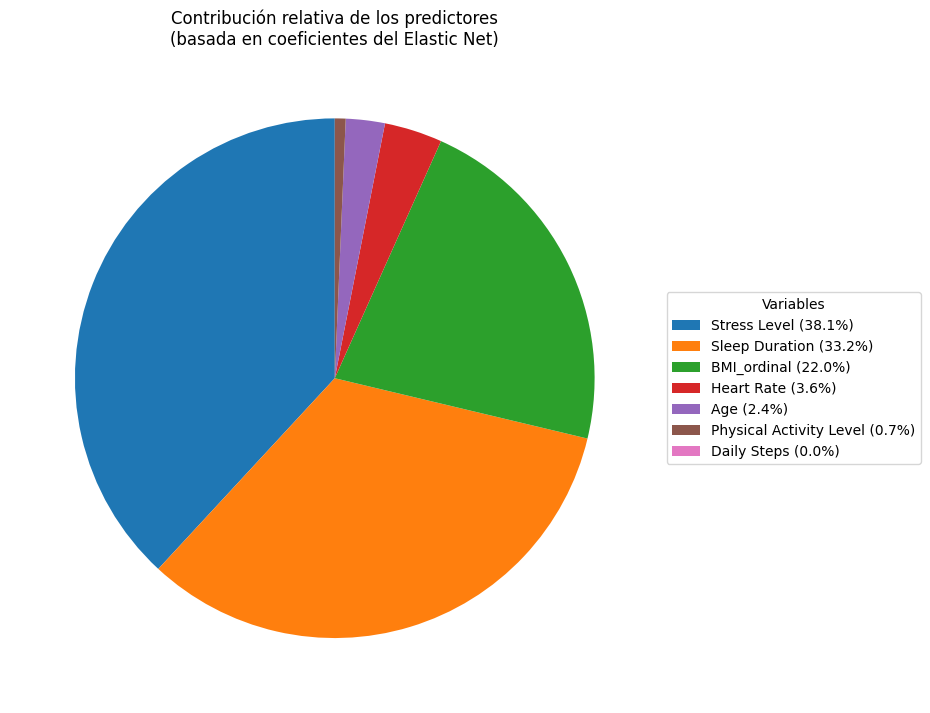

In [30]:
plt.figure(figsize=(9, 8))

labels_leyenda = [
    f"{var} ({pct:.1f}%)"
    for var, pct in zip(coef_df['Variable'], coef_df['Contribucion_rel_%'])
]

plt.figure(figsize=(9, 8))

wedges, texts = plt.pie(
    coef_df['Contribucion_rel_%'],
    labels=None,
    startangle=90,
)

plt.legend(
    wedges,
    labels_leyenda,
    title='Variables',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Contribución relativa de los predictores\n(basada en coeficientes del Elastic Net)')
plt.tight_layout()
plt.show()

### Interpretación del gráfico de contribución

El gráfico indica que tres variables concentran prácticamente todo el peso del modelo:

- **Stress Level:** ~**38.1 %**
- **Sleep Duration:** ~**33.2 %**
- **BMI_ordinal:** ~**22.0 %**

En conjunto, estas tres variables suman aproximadamente **93.3 %** de la contribución relativa representada por el modelo.  
Esto permite sostener una conclusión fuerte y respaldable: **la calidad del sueño en este conjunto de datos está explicada principalmente por el nivel de estrés, la duración del sueño y la categoría de IMC**, mientras que edad, actividad física, frecuencia cardíaca y pasos diarios tienen un papel comparativamente menor en el ajuste final.

Además, la dirección de los coeficientes complementa esta lectura:
- mayor **estrés**  → menor calidad del sueño,
- mayor **duración del sueño** → mayor calidad del sueño,
- peor **categoría de IMC** → menor calidad del sueño.

**Síntesis del modelo:** el patrón global que emerge del análisis es coherente: mejores hábitos y condiciones fisiológicas más favorables se asocian con mejor calidad de sueño, mientras que el estrés y un IMC menos favorable se asocian con un deterioro de la misma. La importancia relativa del estrés y de la duración del sueño sugiere que estas variables son los ejes centrales de la predicción obtenida.

## 10. Ejemplo de predicción individual

Para ilustrar el uso del modelo final, se selecciona una observación real del conjunto y se compara la predicción con el valor observado.  
Además, se descompone la predicción en aportes por variable.

In [17]:
import random

pos = random.randint(0, len(X_test) - 1)

ejemplo = X_test.iloc[[pos]].copy()
pred = pipe_enet_final.predict(ejemplo)[0]
real = y_test.iloc[pos]
error = (np.abs(pred - real) / real) * 100

print("Posición en test:", pos)
print("Predicción del modelo:", pred)
print("Valor real:", real)
print("Error:", error, "%")

print("\nValores del ejemplo:")
print(ejemplo.T)

x_ejemplo = ejemplo.iloc[0]

contrib_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Valor': x_ejemplo.values,
    'Coeficiente': modelo.coef_,
    'Aporte': x_ejemplo.values * modelo.coef_
})

contrib_df = contrib_df.sort_values(by='Aporte', key=abs, ascending=False)

print("\nIntercepto:", modelo.intercept_)
print("Predicción con pipeline:", pred)
print()
print(contrib_df[['Variable', 'Valor', 'Coeficiente', 'Aporte']])


# Predicciones sobre el set de testing
y_pred_test = pipe_enet_final.predict(X_test)

# Métricas
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Métricas en el set de testing")
print("RMSE:", rmse_test)
print("MAE :", mae_test)
print("R2  :", r2_test)

Posición en test: 38
Predicción del modelo: 7.572436958670293
Valor real: 8
Error: 5.344538016621336 %

Valores del ejemplo:
                            152
Age                        39.0
Sleep Duration              7.2
Physical Activity Level    60.0
Stress Level                5.0
Heart Rate                 68.0
Daily Steps              8000.0
BMI_ordinal                 0.0

Intercepto: 7.551483128506558
Predicción con pipeline: 7.572436958670293

                  Variable   Valor  Coeficiente    Aporte
1           Sleep Duration     7.2     0.338065  2.434066
4               Heart Rate    68.0    -0.028763 -1.955890
3             Stress Level     5.0    -0.361086 -1.805430
0                      Age    39.0     0.022515  0.878079
2  Physical Activity Level    60.0     0.006224  0.373463
5              Daily Steps  8000.0     0.000012  0.096666
6              BMI_ordinal     0.0    -0.200089 -0.000000
Métricas en el set de testing
RMSE: 0.3160738607317302
MAE : 0.2627111759710894


### Lectura del ejemplo de predicción

En la observación seleccionada, el modelo predijo una calidad del sueño de **7.57** frente a un valor observado de **8.00**, lo que corresponde a un error relativo cercano al **5.34 %**.  
Este resultado es coherente con el buen desempeño promedio observado en validación cruzada.

El desglose por aportes muestra que, para este caso particular:

- **`Stress Level`** y **`Heart Rate`** empujan la predicción hacia abajo.
- **`Sleep Duration`**, **`Age`** y **`Physical Activity Level`** empujan la predicción hacia arriba.
- **`BMI_ordinal`** también reduce la predicción, aunque con menor magnitud que el estrés y la frecuencia cardíaca.
- **`Daily Steps`** aporta muy poco.

Esta descomposición confirma que la predicción del modelo no es arbitraria: la salida final surge de la combinación coherente de los factores identificados como más relevantes en el análisis global.

También se agrega que el desempeño final del modelo se evaluó sobre un conjunto de prueba no usado durante el entrenamiento. Las métricas obtenidas en este conjunto permiten estimar de manera más realista la capacidad de generalización del modelo.

## 11. Conclusiones finales

A partir del análisis exploratorio y predictivo realizado, se puede concluir lo siguiente:

1. **Existe una relación negativa entre frecuencia cardíaca y calidad del sueño**, pero la relación observada es lo suficientemente lineal como para conservar `Heart Rate` en su escala original.
2. **Elastic Net fue claramente superior a la red neuronal estándar** para este conjunto de datos, con menor error y una capacidad explicativa mucho mayor.
3. **El nivel de estrés, la duración del sueño y la categoría de IMC son los factores dominantes del modelo**, concentrando alrededor del 93 % de la contribución relativa representada por los coeficientes.
4. **El estrés aparece como el principal factor de deterioro de la calidad del sueño**, mientras que dormir más horas aparece como el principal factor de mejora dentro del modelo.
5. **La utilidad práctica del modelo queda respaldada por el ejemplo de predicción**, donde el error fue bajo y los aportes por variable fueron consistentes con la interpretación global.

En conjunto, el análisis sugiere que, para este conjunto de datos, la calidad del sueño puede modelarse de forma precisa mediante un enfoque lineal regularizado y que las variables más influyentes se relacionan con **estrés, duración del sueño y estado corporal general**.

### Alcance y cautela interpretativa
Este análisis es **predictivo**, no causal. Por tanto, los resultados permiten hablar de asociación y capacidad de predicción, pero no demostrar que una variable cause directamente cambios en la calidad del sueño.

### Recomendaciones
- comparar con una versión estandarizada de los predictores para reforzar la lectura de importancia relativa,
- incorporar codificación *one-hot* de variables categóricas eliminadas,
- evaluar importancia por permutación como complemento a los coeficientes,
